In [1]:
import NNMFit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import matplotlib.font_manager as font_manager
font_axis_label = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }
font_title = {'family': 'serif',
        'color':  'black',
        'weight': 'bold',
        'size': 20,
        }
font_legend = font_manager.FontProperties(family='serif',
                                   weight='normal',
                                   style='normal', size=13)

plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams.update({'font.family':'serif'})

In [3]:
def get_1sigma(scan, parameter, bestfit_val, threshold=1.0):
    """Find where dllh crosses threshold via sign-change detection + linear interpolation."""
    scan_sorted = scan.sort_values(parameter).reset_index(drop=True)
    x = scan_sorted[parameter].values
    delta = scan_sorted["dllh"].values - threshold

    sign_changes = np.where(np.diff(np.sign(delta)))[0]
    roots = []
    for idx in sign_changes:
        x0, x1 = x[idx], x[idx + 1]
        y0, y1 = delta[idx], delta[idx + 1]
        roots.append(x0 - y0 * (x1 - x0) / (y1 - y0))

    roots = np.array(roots)
    lower = roots[roots < bestfit_val]
    upper = roots[roots > bestfit_val]

    err_lo = bestfit_val - lower[-1] if len(lower) else np.nan
    err_hi = upper[0] - bestfit_val if len(upper) else np.nan
    return err_lo, err_hi

In [4]:
scan_dir_dict = {
    "LBFGSB" : "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/LBFGSB/nbestfit20_scan_astro_gamma_1D_10steps_round2",
    "force_full_3_nlight_20" : "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20/nbestfit20_scan_astro_gamma_1D_10steps_round2",
    "force_full_3_nlight_20_round3" : "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20/nbestfit20_scan_astro_gamma_1D_10steps_round3",
}

In [5]:
drop_unsuccessful = True
scan_dict = {}
bestfits = {}

for name, scan_dir in scan_dir_dict.items():
    print(name)
    # use force_read if new scan points are produced
    scan_dict[name] = NNMFit.utilities.ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    bestfits[name] = scan_dict[name].get_freefit(drop_unsuccessful="True")

LBFGSB
force_full_3_nlight_20
force_full_3_nlight_20_round3


## Best fit comparison

Compare best fit parameter values across all scans and identify which optimizer found the lowest likelihood.

In [6]:
# Compare best fit values across all scans
df_compare = pd.DataFrame({name: bestfits[name] for name in scan_dir_dict}).T
display(df_compare)

best_name = df_compare["llh"].idxmin()
print(f"\nBest likelihood: '{best_name}'  (llh = {df_compare.loc[best_name, 'llh']:.6f})")
for name in scan_dir_dict:
    if name != best_name:
        delta = df_compare.loc[name, "llh"] - df_compare.loc[best_name, "llh"]
        print(f"  {name} is worse by dllh = {delta:.4f}")

,CR_grad,astro_norm,barr_h,barr_w,barr_y,barr_z,conv_norm,delta_gamma,dom_eff,fit_success,gamma_astro,ice_abs,ice_crystal,ice_holep0,ice_holep1,ice_scat,llh,muongun_norm,prompt_norm
LBFGSB,-0.298444,2.14541,0.003747,0.028945,0.1095,0.056235,1.059861,-0.002807,1.012427,1.0,2.780075,1.059974,0.926034,0.13958,-0.080107,0.945844,212.875692,1.434795,0.0
force_full_3_nlight_20,-0.301747,2.244255,0.004261,0.03614,0.1152,0.059363,1.063822,-0.002431,0.970823,1.0,2.817527,1.07668,0.85305,0.045779,-0.095052,0.946482,212.860606,1.457239,0.0
force_full_3_nlight_20_round3,-0.305528,2.241318,0.004321,0.036249,0.116215,0.059073,1.063399,-0.00264,0.971212,1.0,2.816158,1.076885,0.852608,0.045653,-0.094963,0.946719,212.86065,1.459073,0.0



Best likelihood: 'force_full_3_nlight_20'  (llh = 212.860606)
  LBFGSB is worse by dllh = 0.0151
  force_full_3_nlight_20_round3 is worse by dllh = 0.0000


## Free fit parameter distributions

Histograms of all free parameters across the best-fit ensemble. The red line marks the best fit value for each parameter.

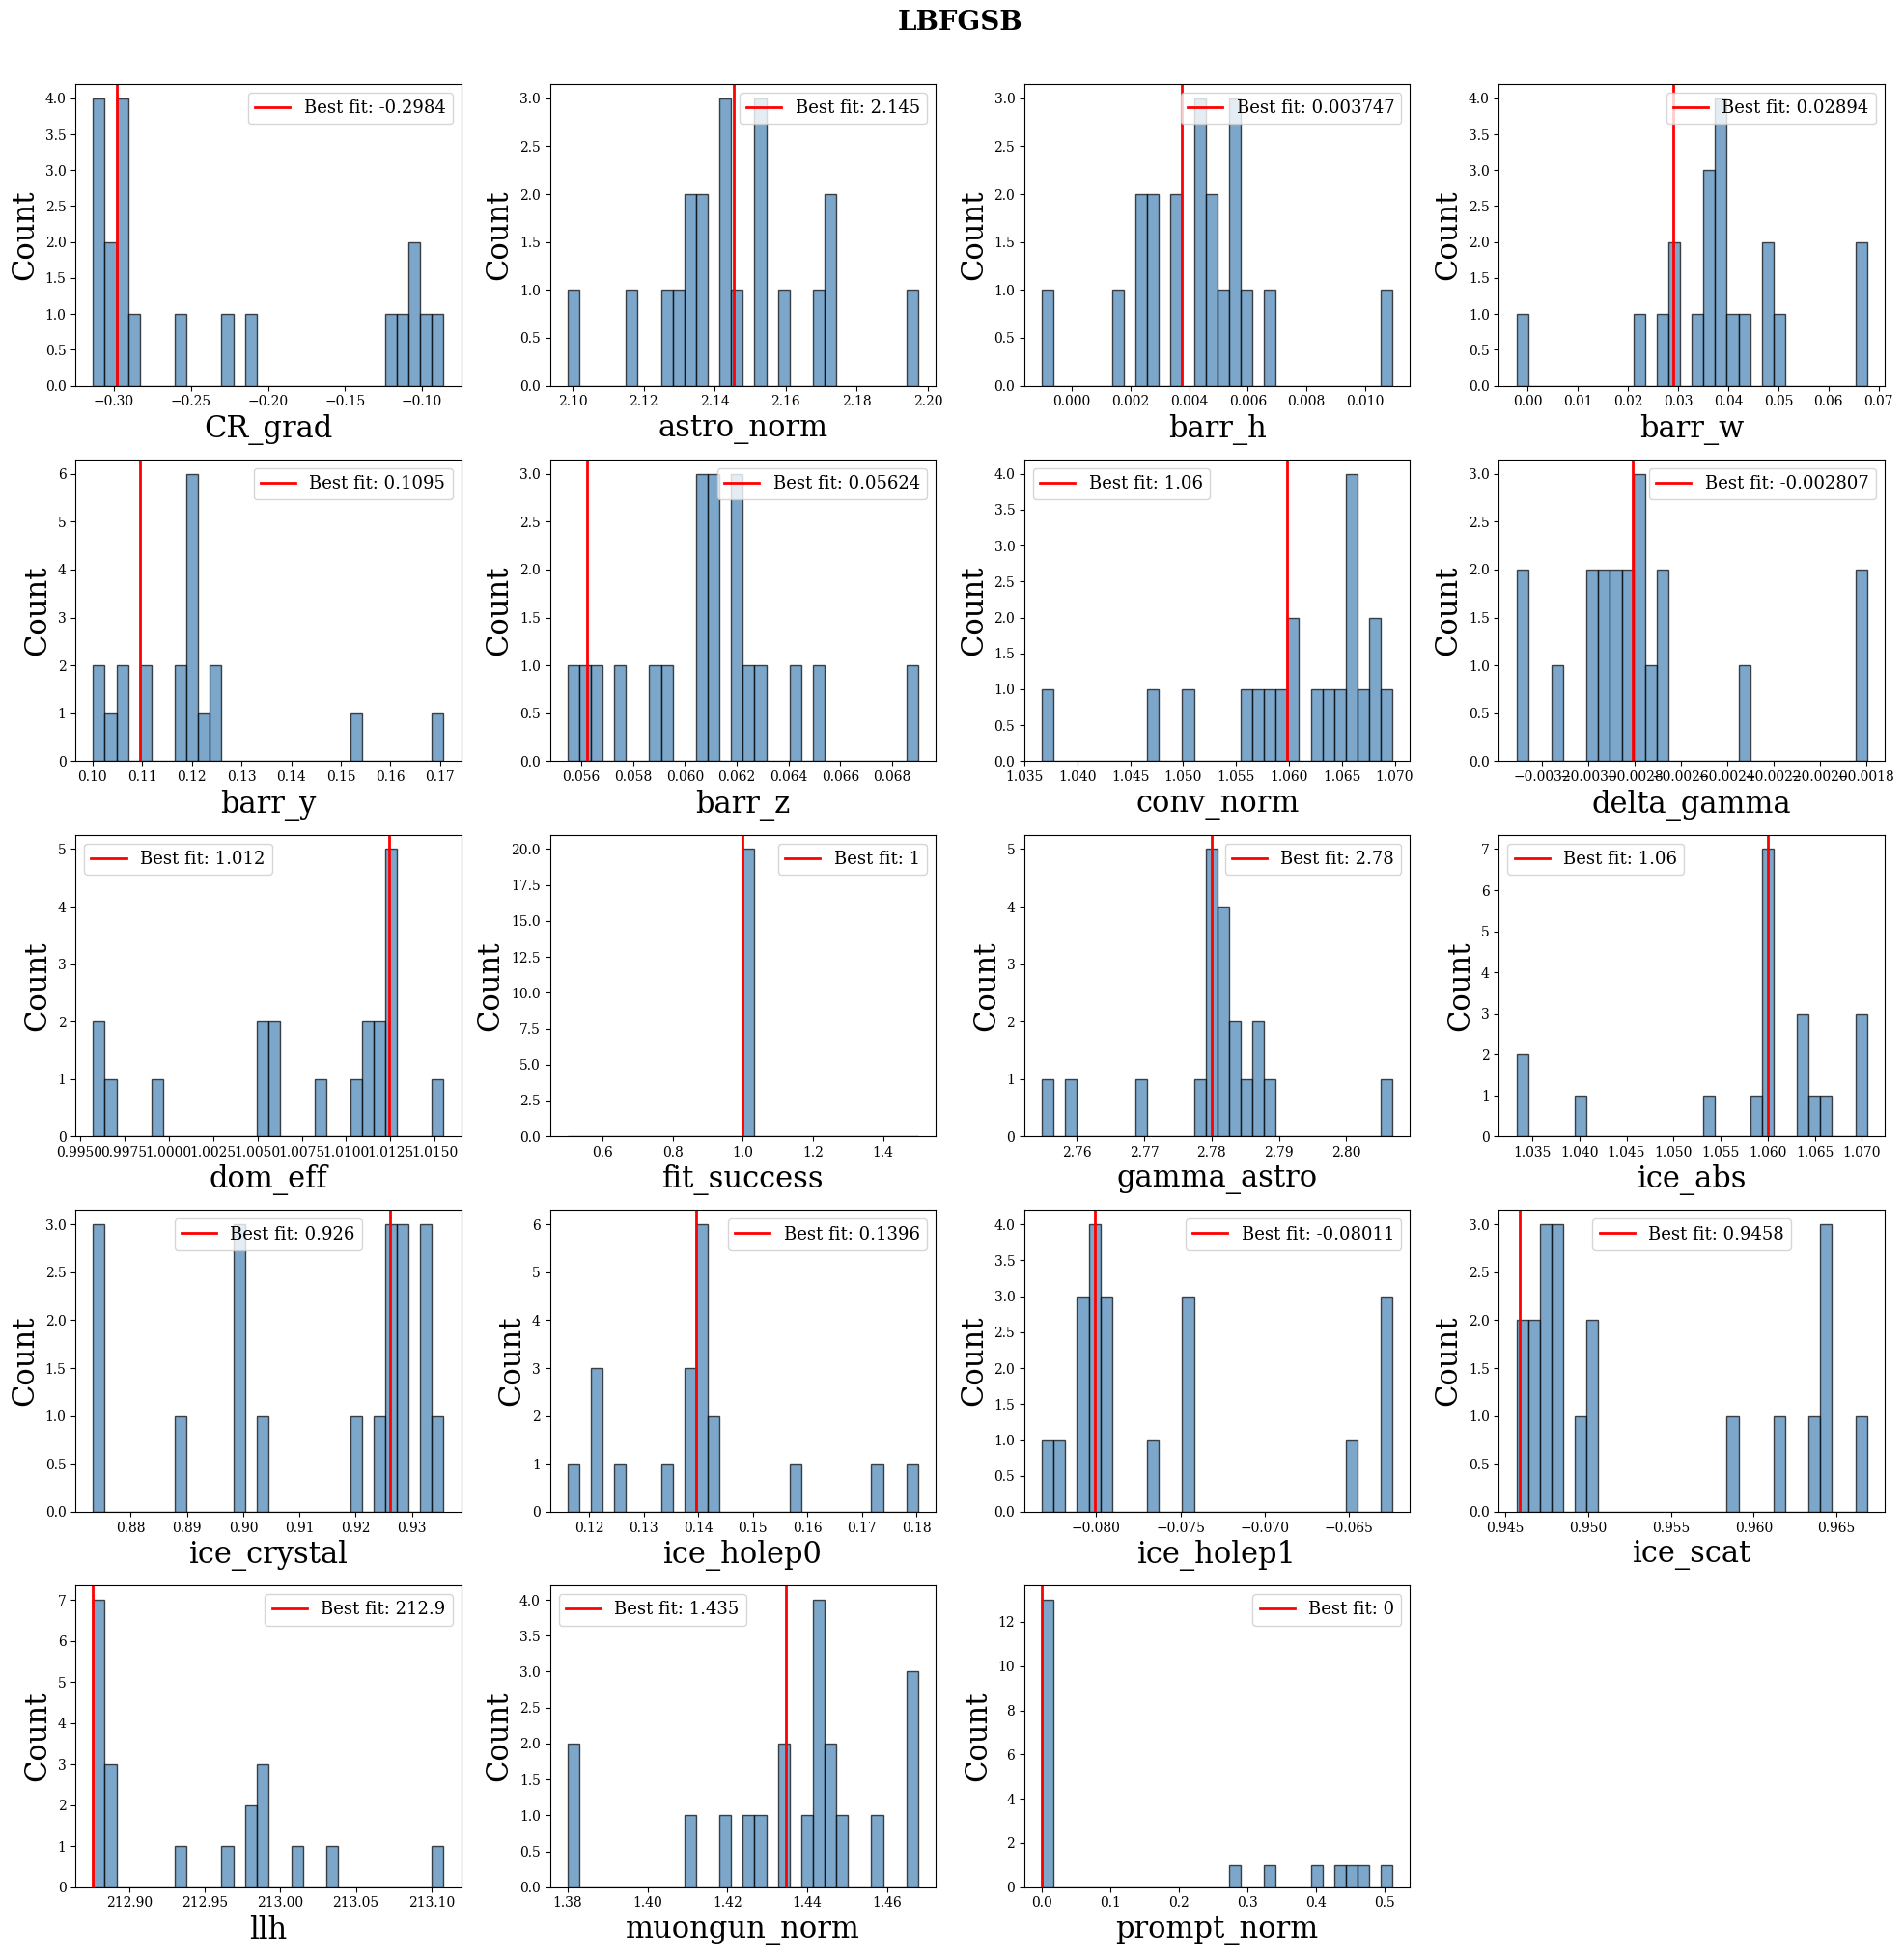

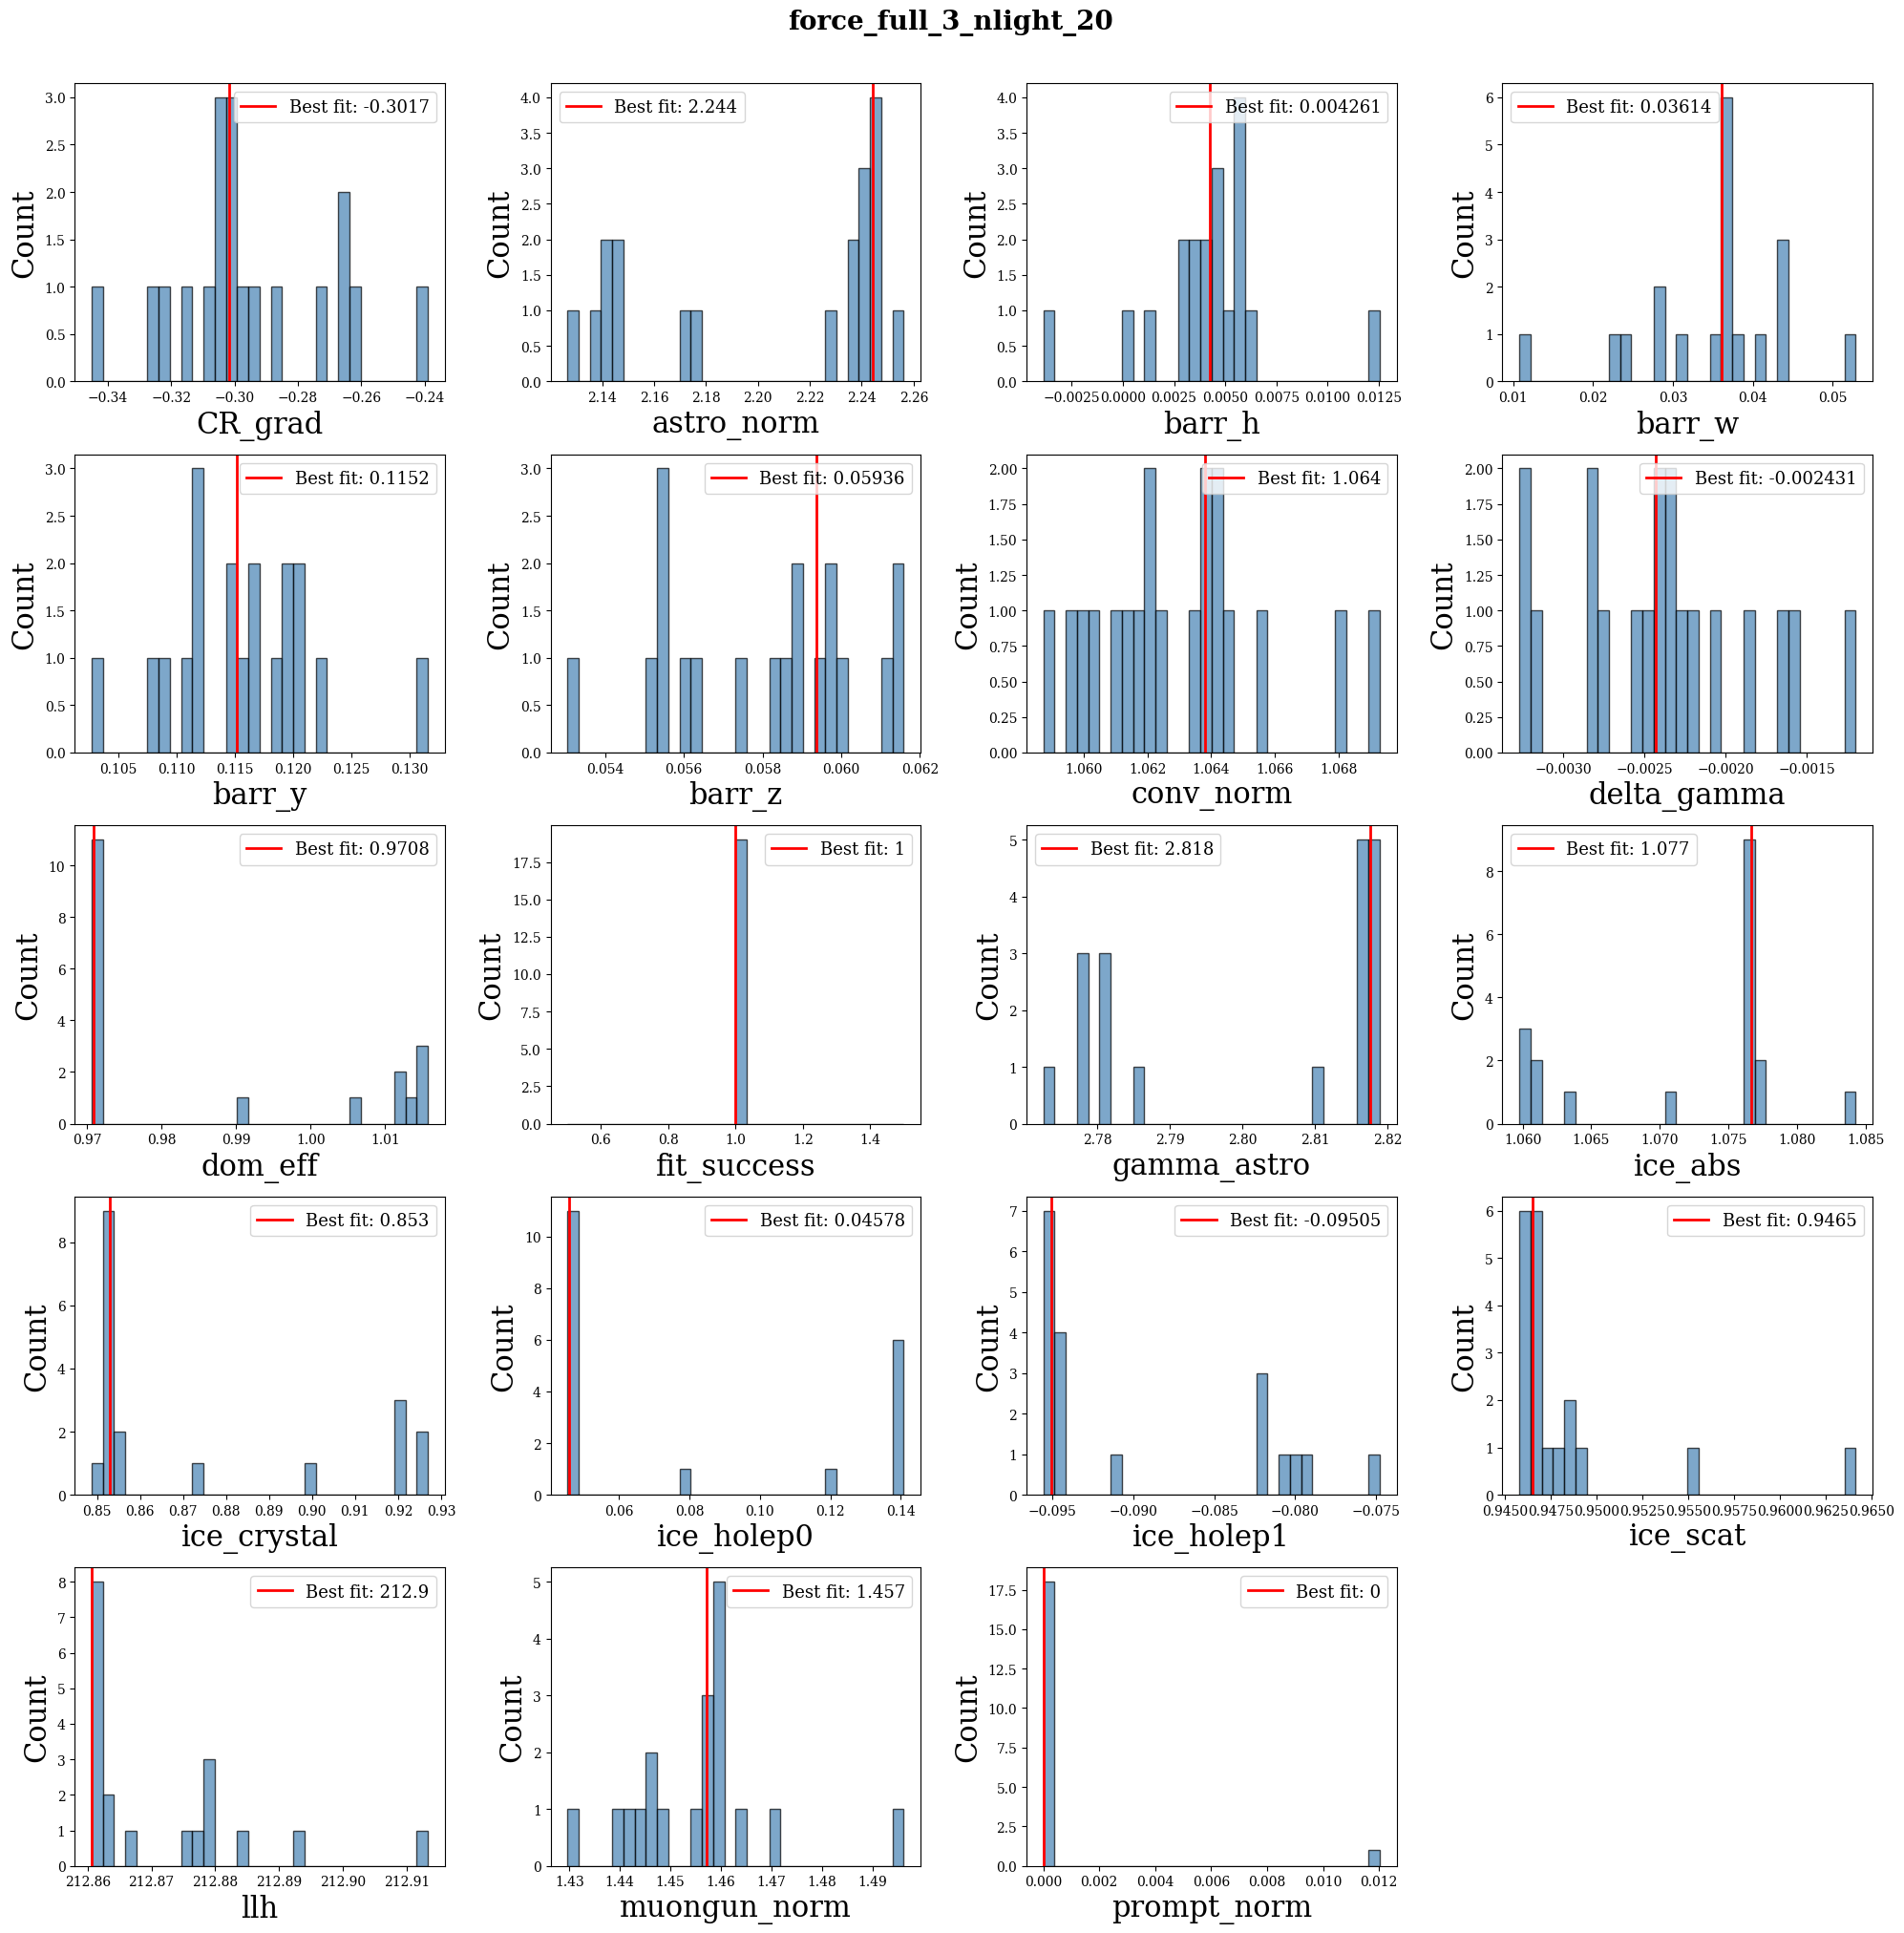

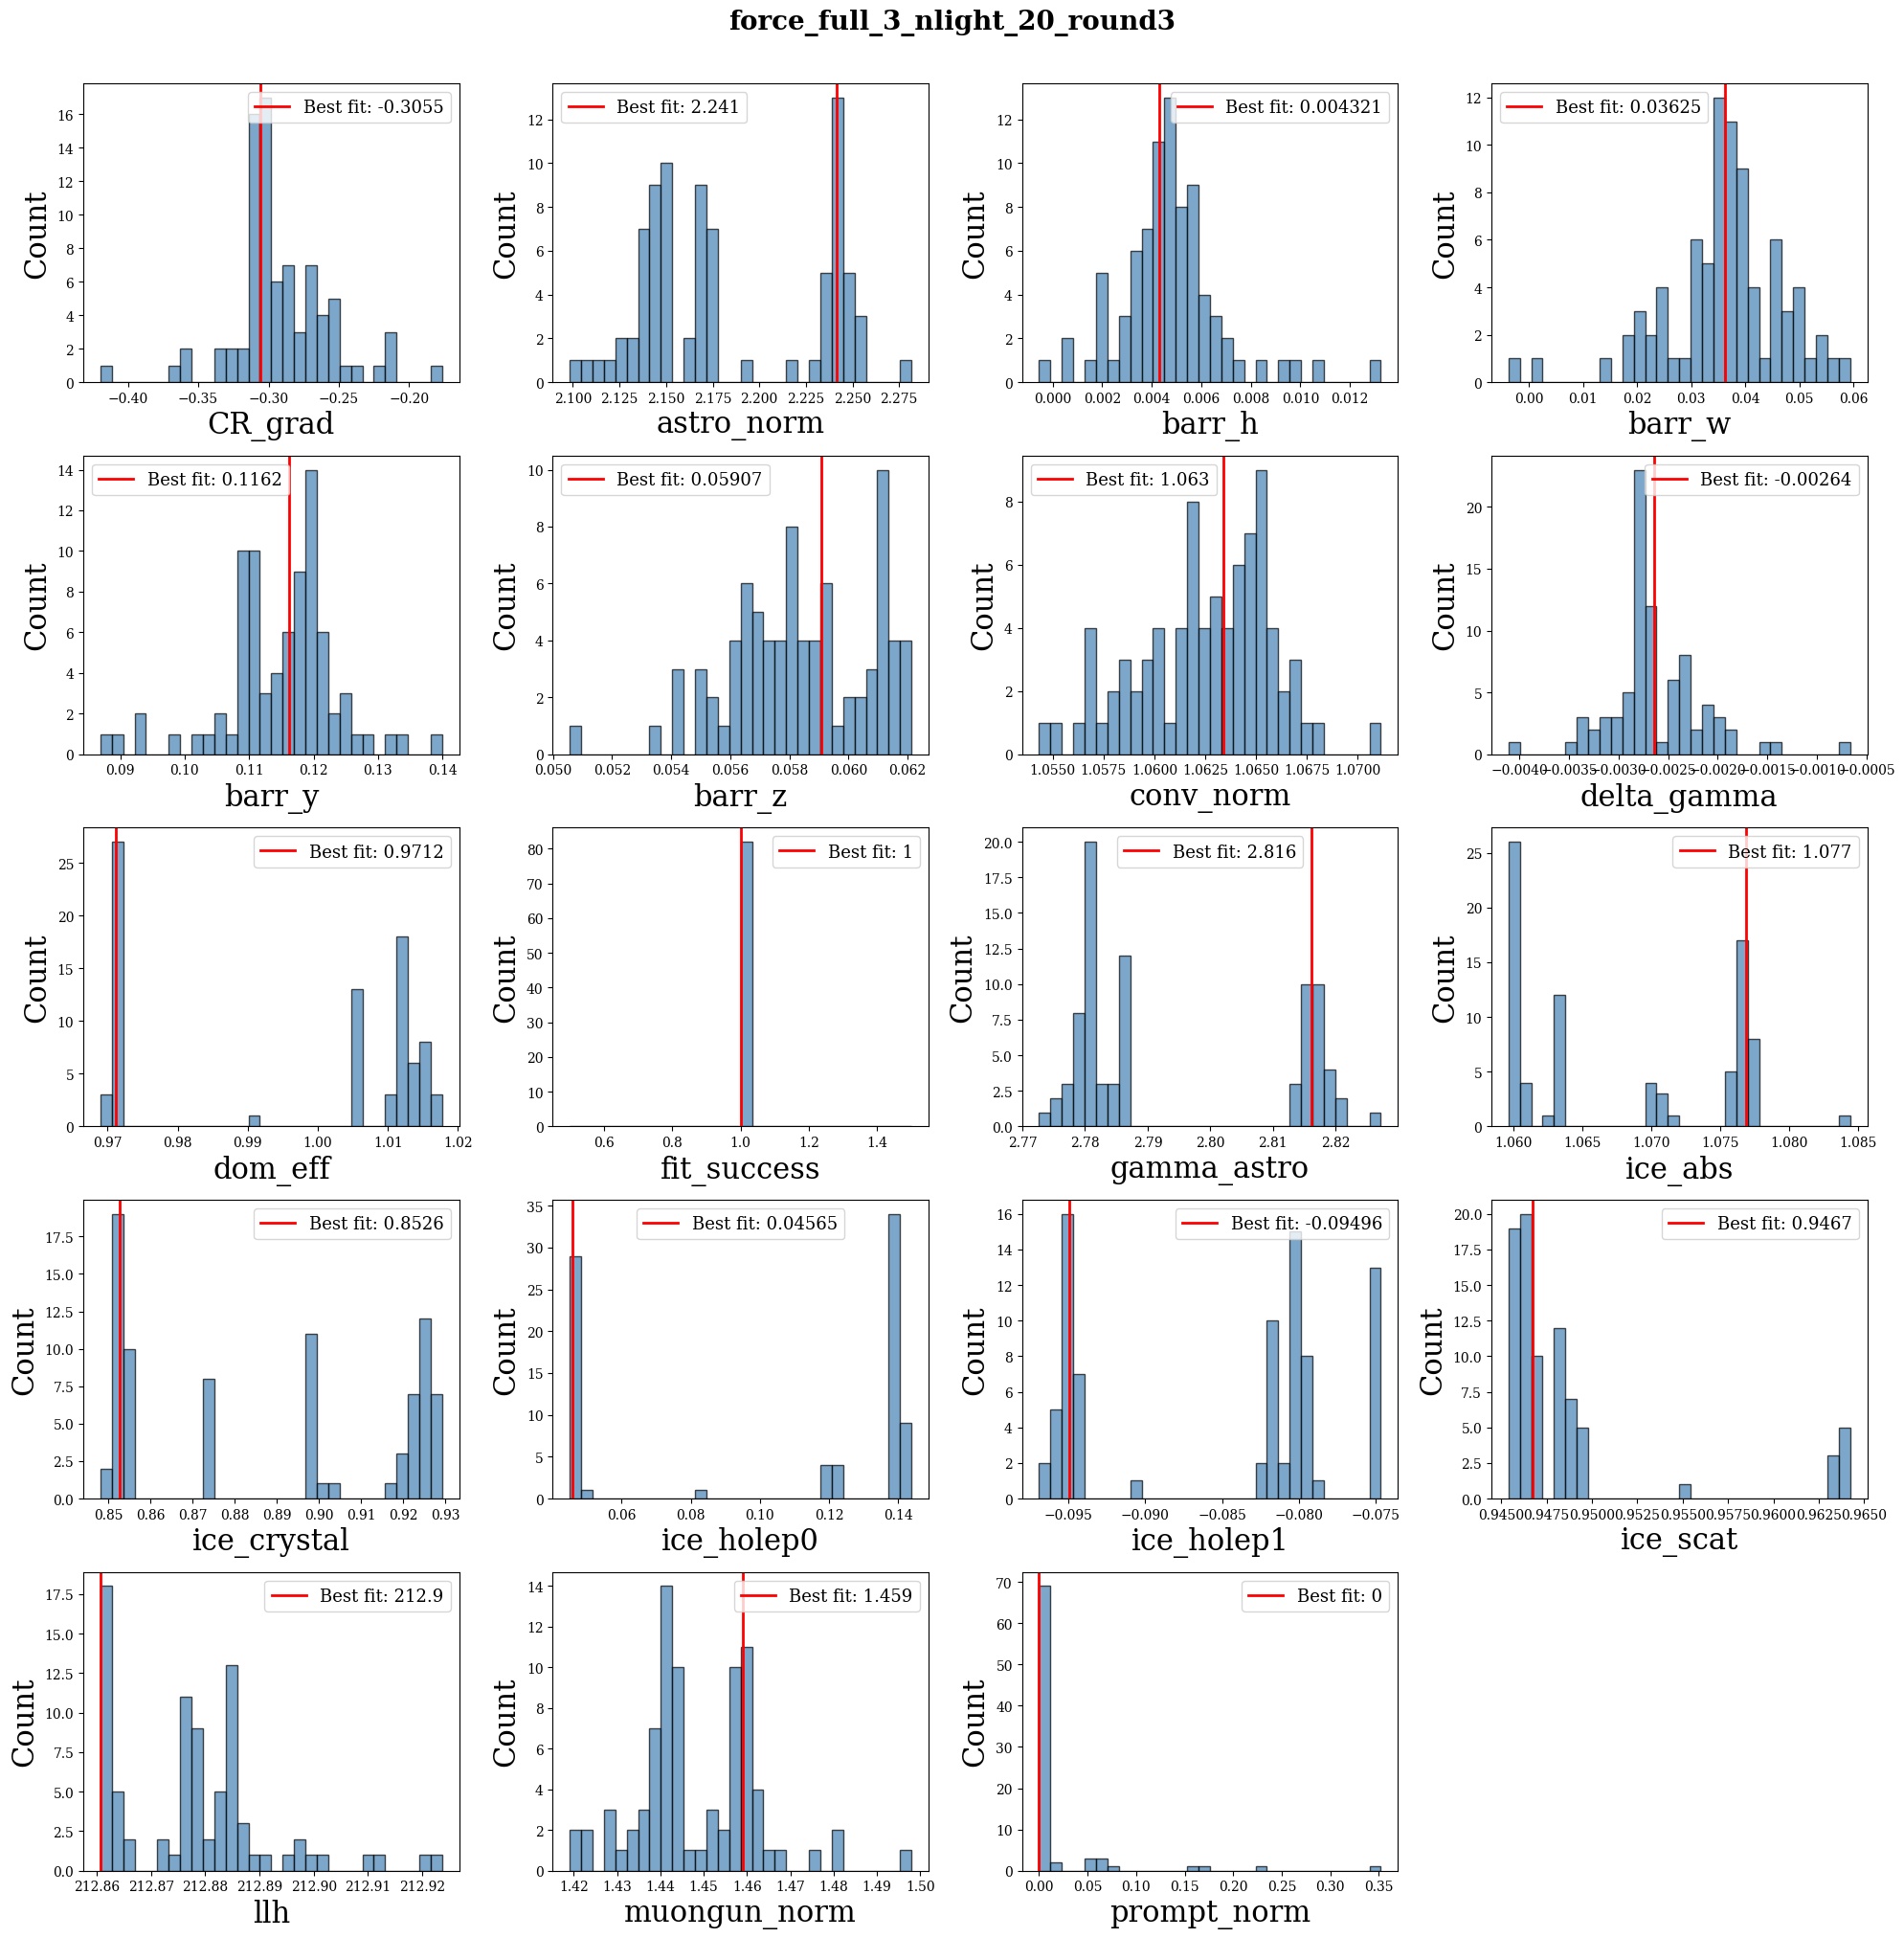

In [31]:
for name in scan_dir_dict:
    freefit_df = scan_dict[name].get_raw_df().loc["freefit"]
    variables = freefit_df.keys()
    bestfit = bestfits[name]

    ncols = 4
    nrows = int(np.ceil(len(variables) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    fig.suptitle(name, **font_title, y=1.01)
    axes = axes.flatten()

    for i, var in enumerate(variables):
        ax = axes[i]
        values = freefit_df[var].dropna()
        ax.hist(values, bins=30, color="steelblue", alpha=0.7, edgecolor="black")
        if var in bestfit:
            bf_val = bestfit[var]
            ax.axvline(x=bf_val, color="red", linewidth=2, label=f"Best fit: {bf_val:.4g}")
            ax.legend(prop=font_legend)
        ax.set_xlabel(var, fontdict=font_axis_label)
        ax.set_ylabel("Count", fontdict=font_axis_label)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


## Likelihood scan comparison

Overlay of the $-2\Delta\log\mathcal{L}$ profiles for `astro_norm` and `gamma_astro` across all scans. Dashed verticals mark each best fit; dotted verticals mark the 1σ boundaries.

LBFGSB | astro_norm: 2.145 +0.1599 / -nan
force_full_3_nlight_20 | astro_norm: 2.244 +0.3547 / -0.4471
force_full_3_nlight_20_round3 | astro_norm: 2.241 +0.3425 / -0.4466
LBFGSB | gamma_astro: 2.78 +0.1786 / -0.1346
force_full_3_nlight_20 | gamma_astro: 2.818 +0.1388 / -0.1703
force_full_3_nlight_20_round3 | gamma_astro: 2.816 +0.1292 / -0.1689


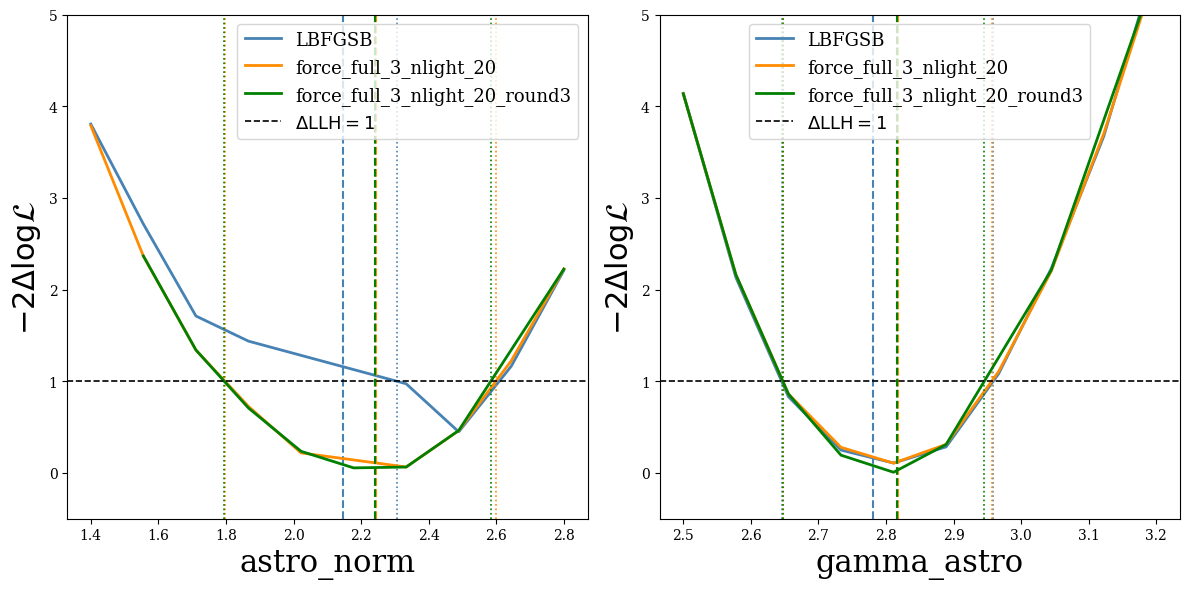

In [32]:
parameters = ["astro_norm", "gamma_astro"]
colors = ["steelblue", "darkorange", "green"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, parameter in zip(axes, parameters):
    for color, name in zip(colors, scan_dir_dict):
        scan = scan_dict[name].get_scan_df(param_name=parameter, drop_unsuccessful=drop_unsuccessful)
        bestfit_val = bestfits[name][parameter]
        err_lo, err_hi = get_1sigma(scan, parameter, bestfit_val)

        print(f"{name} | {parameter}: {bestfit_val:.4g} +{err_hi:.4g} / -{err_lo:.4g}")

        scan_sorted = scan.sort_values(parameter)
        ax.plot(scan_sorted[parameter], scan_sorted["dllh"], color=color, linewidth=2, label=name)
        ax.axvline(bestfit_val, color=color, linewidth=1.5, linestyle="--")
        ax.axvline(bestfit_val - err_lo, color=color, linestyle=":", linewidth=1.2)
        ax.axvline(bestfit_val + err_hi, color=color, linestyle=":", linewidth=1.2)

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label=r"$\Delta\mathrm{LLH} = 1$")
    ax.set_xlabel(parameter, fontdict=font_axis_label)
    ax.set_ylabel(r"$-2\Delta\mathrm{log}\mathcal{L}$", fontdict=font_axis_label)
    ax.set_ylim(-0.5, 5)
    ax.legend(prop=font_legend)

plt.tight_layout()
plt.show()


## Best fit scan — 1σ errors

Likelihood profile for `astro_norm` and `gamma_astro` from the best scan. The red shaded band marks the 1σ interval where $-2\Delta\log\mathcal{L} < 1$.

<>:20: DeprecationWarning: invalid escape sequence '\s'
<>:20: DeprecationWarning: invalid escape sequence '\s'
/tmp/ipykernel_3865519/1342605429.py:20: DeprecationWarning: invalid escape sequence '\s'
  label=f"$1\sigma$: $+{err_hi:.4g}$ / $-{err_lo:.4g}$")


astro_norm: 2.244 +0.3547 / -0.4471
gamma_astro: 2.818 +0.1388 / -0.1703


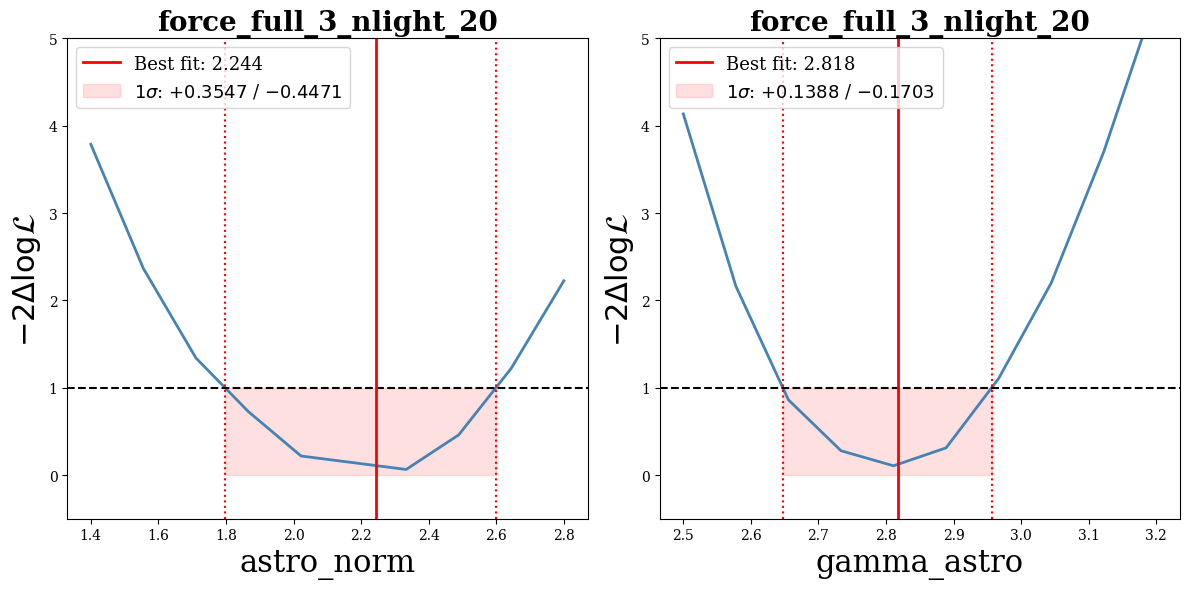

In [33]:
parameters = ["astro_norm", "gamma_astro"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, parameter in zip(axes, parameters):
    scan = scan_dict[best_name].get_scan_df(param_name=parameter, drop_unsuccessful=drop_unsuccessful)
    bestfit_val = bestfits[best_name][parameter]
    err_lo, err_hi = get_1sigma(scan, parameter, bestfit_val)

    print(f"{parameter}: {bestfit_val:.4g} +{err_hi:.4g} / -{err_lo:.4g}")

    scan_sorted = scan.sort_values(parameter)
    ax.plot(scan_sorted[parameter], scan_sorted["dllh"], color="steelblue", linewidth=2)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(bestfit_val, color="red", linewidth=2, label=f"Best fit: {bestfit_val:.4g}")
    ax.axvline(bestfit_val - err_lo, color="red", linestyle=":", linewidth=1.5)
    ax.axvline(bestfit_val + err_hi, color="red", linestyle=":", linewidth=1.5)
    ax.fill_betweenx([0, 1], bestfit_val - err_lo, bestfit_val + err_hi,
                     color="red", alpha=0.12,
                     label=f"$1\sigma$: $+{err_hi:.4g}$ / $-{err_lo:.4g}$")

    ax.set_xlabel(parameter, fontdict=font_axis_label)
    ax.set_ylabel(r"$-2\Delta\mathrm{log}\mathcal{L}$", fontdict=font_axis_label)
    ax.set_title(best_name, **font_title)
    ax.set_ylim(-0.5, 5)
    ax.legend(prop=font_legend)

plt.tight_layout()
plt.show()


## Best fit parameters

Parameters from the best scan printed in `input_params` YAML format, ready to paste into the analysis config.

In [7]:
bf = bestfits[best_name]

signal      = ["astro_norm", "gamma_astro"]
flux_nuis   = ["conv_norm", "prompt_norm", "muongun_norm",
               "CR_grad", "barr_h", "barr_w", "barr_y", "barr_z", "delta_gamma"]
det_nuis    = ["dom_eff", "ice_abs", "ice_crystal", "ice_holep0", "ice_holep1", "ice_scat"]

lines = [f"# best fit from scan: {best_name}", "input_params:"]
for label, group in [("signal", signal), ("flux nuisance", flux_nuis), ("detector nuisance", det_nuis)]:
    lines.append(f"  ### {label}")
    for p in group:
        lines.append(f"  {p}: {bf[p]}")
    lines.append("")

print("\n".join(lines))

# best fit from scan: force_full_3_nlight_20
input_params:
  ### signal
  astro_norm: 2.2442548547245496
  gamma_astro: 2.81752715186688

  ### flux nuisance
  conv_norm: 1.0638217360248496
  prompt_norm: 0.0
  muongun_norm: 1.4572392109257732
  CR_grad: -0.30174744927067926
  barr_h: 0.004260894125801356
  barr_w: 0.03613960115381407
  barr_y: 0.11519971610547383
  barr_z: 0.05936337444350018
  delta_gamma: -0.002431016314179412

  ### detector nuisance
  dom_eff: 0.9708232949179527
  ice_abs: 1.0766800688488438
  ice_crystal: 0.8530497408529658
  ice_holep0: 0.04577855321469167
  ice_holep1: -0.09505178600612336
  ice_scat: 0.9464817792670911



In [8]:
bestfits[best_name]
idx = bestfits[best_name].name
idx

17